# KeduaKali — A/B Testing: Dampak Promosi terhadap Penjualan & Sisa Makanan

---
**KeduaKali** adalah platform cerdas penyelamat makanan *leftover* di Indonesia yang menghubungkan restoran dengan konsumen untuk mengurangi pemborosan pangan. Platform ini beroperasi dalam ekosistem *Sustainable & Responsible Consumption*, menyelaraskan profitabilitas bisnis restoran dengan dampak sosial dan lingkungan.

Dataset yang digunakan (`restaurant_sales_cleaned.csv`) berisi **8.583 transaksi restoran** yang sudah melalui proses *data cleaning* dan *label encoding*. Semua kolom sudah dalam format numerik dan siap digunakan langsung untuk analisis statistik.

## Tujuan A/B Testing

Pengujian ini dirancang untuk menjawab dua pertanyaan bisnis kritis:

1. **Apakah promosi secara signifikan meningkatkan penjualan?** (`quantity_sold` lebih tinggi)
2. **Apakah promosi secara signifikan mengurangi sisa makanan?** (`leftover` lebih rendah)

Hasil uji ini akan menjadi dasar keputusan untuk fitur **Smart Promotion** di platform KeduaKali.

---

## 1. Perancangan Eksperimen

### Definisi Grup
| Grup | Kondisi | Deskripsi |
|------|---------|------------|
| **Grup A (Kontrol)** | `has_promotion == 0` | Transaksi tanpa promosi |
| **Grup B (Perlakuan)** | `has_promotion == 1` | Transaksi dengan promosi |

### Hipotesis

**Uji 1 — Konversi Penjualan (`quantity_sold`)**
- **H₀**: Tidak ada perbedaan tingkat penjualan tinggi antara Grup A dan Grup B (p_A = p_B)
- **H₁**: Ada perbedaan tingkat penjualan tinggi antara Grup A dan Grup B (p_A ≠ p_B)

**Uji 2 — Efisiensi Waste (`leftover`)**
- **H₀**: Tidak ada perbedaan tingkat efisiensi sisa makanan antara Grup A dan Grup B (p_A = p_B)
- **H₁**: Ada perbedaan tingkat efisiensi sisa makanan antara Grup A dan Grup B (p_A ≠ p_B)

### Parameter Statistik
- **Alpha (α)**: 0.05
- **Confidence Level**: 95%
- **Jenis Uji**: *Two-sided test*

### Metode Utama: Z-Test untuk Proporsi (`proportions_ztest`)

Metode ini dipilih karena:
- **Ukuran sampel besar** (n > 30 di kedua grup) → distribusi sampling mendekati normal (Central Limit Theorem)
- Variabel kontinu (`quantity_sold`, `leftover`) dikonversi ke **metrik biner** terlebih dahulu sehingga uji proporsi bisa diterapkan
- Z-Test proporsi memberikan interpretasi bisnis yang lebih langsung: *"berapa persen transaksi yang berhasil?"*
- Tersedia via `statsmodels.stats.proportion.proportions_ztest` — stabil dan tersedia di Google Colab

> **Transparansi metodologi**: Sebelum menjalankan Z-Test, dilakukan *assumption checking* (Shapiro-Wilk + Levene) untuk mendokumentasikan karakteristik distribusi data. Hasil assumption checking **tidak mengubah pilihan metode** — Z-Test tetap digunakan karena justifikasi CLT pada sampel besar — namun penting untuk kelengkapan laporan ilmiah.

---

## 2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import gdown

np.random.seed(42)
print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


## 3. Load Dataset

In [ ]:
file_id = "172-LOh7kSP4qKJ3vZGHlHMIIEgAsE-3X"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "restaurant_sales_cleaned.csv", quiet=False)

df = pd.read_csv('restaurant_sales_cleaned.csv')

print(f"Shape dataset: {df.shape}")
print(f"\nTipe data kolom:")
print(df.dtypes)
print(f"\nSample 5 baris pertama:")
df.head(5)

Downloading...
From: https://drive.google.com/uc?id=172-LOh7kSP4qKJ3vZGHlHMIIEgAsE-3X
To: /content/restaurant_sales_cleaned.csv
100%|██████████| 347k/347k [00:00<00:00, 84.5MB/s]

Shape dataset: (8583, 9)

Tipe data kolom:
quantity_sold          int64
price_diff           float64
leftover             float64
restaurant_type        int64
meal_type              int64
menu_item_name         int64
has_promotion          int64
special_event          int64
weather_condition      int64
dtype: object

Sample 5 baris pertama:


,quantity_sold,price_diff,leftover,restaurant_type,meal_type,menu_item_name,has_promotion,special_event,weather_condition
0,361,1.89,0.0000,3,2,7,0,0,2
1,503,0.44,0.0000,3,1,10,0,0,2
2,262,15.24,24.0004,2,2,11,0,0,1
3,409,1.92,0.0000,3,2,1,0,0,2
4,236,5.85,50.0004,3,1,2,0,0,0


## 4. Persiapan Grup Eksperimen

Dataset dipisah berdasarkan kolom `has_promotion`:
- **Grup A**: `has_promotion == 0` → transaksi tanpa promo (kontrol)
- **Grup B**: `has_promotion == 1` → transaksi dengan promo (perlakuan)

In [ ]:
grup_A = df[df['has_promotion'] == 0].copy()
grup_B = df[df['has_promotion'] == 1].copy()

print(f"Jumlah observasi:")
print(f"  Grup A (Tanpa Promo): {len(grup_A):,} transaksi")
print(f"  Grup B (Ada Promo)  : {len(grup_B):,} transaksi")
print(f"  Total               : {len(df):,} transaksi")

print(f"\nStatistik Deskriptif per Grup (quantity_sold & leftover):")
df.groupby('has_promotion')[['quantity_sold', 'leftover']].describe().round(2)

Jumlah observasi:
  Grup A (Tanpa Promo): 7,401 transaksi
  Grup B (Ada Promo)  : 1,182 transaksi
  Total               : 8,583 transaksi

Statistik Deskriptif per Grup (quantity_sold & leftover):


quantity_sold                                              \
                      count    mean     std  min     25%    50%     75%   
has_promotion                                                             
0                    7401.0  262.43  163.76  0.0  141.00  245.0  369.00   
1                    1182.0  376.79  193.40  0.0  224.25  357.0  536.75   

                     leftover                                               
                 max    count   mean    std  min  25%   50%     75%    max  
has_promotion                                                               
0              749.0   7401.0  79.76  92.01  0.0  0.0  41.0  145.00  286.0  
1              749.0   1182.0  41.13  71.23  0.0  0.0   0.0   61.75  286.0

## 5. Assumption Checking (Transparansi Metodologi)

Sebelum menjalankan Z-Test, kita dokumentasikan karakteristik distribusi data melalui dua uji:

- **Shapiro-Wilk Test**: menguji apakah distribusi data mendekati normal
- **Levene's Test**: menguji homogenitas varians antara kedua grup

> ⚠️ **Catatan penting**: Dengan ukuran sampel > 8.000, Shapiro-Wilk hampir pasti akan menolak normalitas — ini bukan masalah, karena Z-Test untuk proporsi sudah dijustifikasi oleh **Central Limit Theorem** pada sampel besar. Assumption checking ini murni untuk transparansi dan dokumentasi ilmiah.

In [ ]:
alpha = 0.05

print("=" * 60)
print("  ASSUMPTION CHECKING — UJI 1: quantity_sold")
print("=" * 60)

# Shapiro-Wilk (subsample max 5000 karena limitasi scipy)
shapiro_A_qty = stats.shapiro(grup_A['quantity_sold'].sample(min(5000, len(grup_A)), random_state=42))
shapiro_B_qty = stats.shapiro(grup_B['quantity_sold'].sample(min(5000, len(grup_B)), random_state=42))

print(f"\n[Shapiro-Wilk] Normalitas quantity_sold:")
print(f"  Grup A — Statistic: {shapiro_A_qty.statistic:.4f}, p-value: {shapiro_A_qty.pvalue:.6f}")
print(f"  Grup B — Statistic: {shapiro_B_qty.statistic:.4f}, p-value: {shapiro_B_qty.pvalue:.6f}")

norm_qty_met = (shapiro_A_qty.pvalue >= alpha) and (shapiro_B_qty.pvalue >= alpha)
print(f"  → Asumsi normalitas {'TERPENUHI ✅' if norm_qty_met else 'TIDAK terpenuhi ❌ (ekspektasi pada n besar — CLT berlaku)'}")

# Levene
levene_qty = stats.levene(grup_A['quantity_sold'], grup_B['quantity_sold'])
print(f"\n[Levene] Homogenitas varians quantity_sold:")
print(f"  Statistic: {levene_qty.statistic:.4f}, p-value: {levene_qty.pvalue:.6f}")
homogeneity_qty_met = levene_qty.pvalue >= alpha
print(f"  → Asumsi homogenitas varians {'TERPENUHI ✅' if homogeneity_qty_met else 'TIDAK terpenuhi ❌'}")

print()
print("=" * 60)
print("  ASSUMPTION CHECKING — UJI 2: leftover")
print("=" * 60)

shapiro_A_waste = stats.shapiro(grup_A['leftover'].sample(min(5000, len(grup_A)), random_state=42))
shapiro_B_waste = stats.shapiro(grup_B['leftover'].sample(min(5000, len(grup_B)), random_state=42))

print(f"\n[Shapiro-Wilk] Normalitas leftover:")
print(f"  Grup A — Statistic: {shapiro_A_waste.statistic:.4f}, p-value: {shapiro_A_waste.pvalue:.6f}")
print(f"  Grup B — Statistic: {shapiro_B_waste.statistic:.4f}, p-value: {shapiro_B_waste.pvalue:.6f}")

norm_waste_met = (shapiro_A_waste.pvalue >= alpha) and (shapiro_B_waste.pvalue >= alpha)
print(f"  → Asumsi normalitas {'TERPENUHI ✅' if norm_waste_met else 'TIDAK terpenuhi ❌ (ekspektasi pada n besar — CLT berlaku)'}")

levene_waste = stats.levene(grup_A['leftover'], grup_B['leftover'])
print(f"\n[Levene] Homogenitas varians leftover:")
print(f"  Statistic: {levene_waste.statistic:.4f}, p-value: {levene_waste.pvalue:.6f}")
homogeneity_waste_met = levene_waste.pvalue >= alpha
print(f"  → Asumsi homogenitas varians {'TERPENUHI ✅' if homogeneity_waste_met else 'TIDAK terpenuhi ❌'}")

print()
print("=" * 60)
print("  KESIMPULAN ASSUMPTION CHECKING")
print("=" * 60)
print("""
Dengan n > 8.000, penolakan Shapiro-Wilk adalah hal yang wajar
dan TIDAK membatalkan analisis. Berdasarkan Central Limit Theorem,
distribusi sampling rata-rata/proporsi mendekati normal pada
ukuran sampel besar, sehingga Z-Test untuk proporsi tetap valid
dan menjadi pilihan metode yang tepat.""")

  ASSUMPTION CHECKING — UJI 1: quantity_sold

[Shapiro-Wilk] Normalitas quantity_sold:
  Grup A — Statistic: 0.9733, p-value: 0.000000
  Grup B — Statistic: 0.9703, p-value: 0.000000
  → Asumsi normalitas TIDAK terpenuhi ❌ (ekspektasi pada n besar — CLT berlaku)

[Levene] Homogenitas varians quantity_sold:
  Statistic: 107.5285, p-value: 0.000000
  → Asumsi homogenitas varians TIDAK terpenuhi ❌

  ASSUMPTION CHECKING — UJI 2: leftover

[Shapiro-Wilk] Normalitas leftover:
  Grup A — Statistic: 0.8194, p-value: 0.000000
  Grup B — Statistic: 0.6461, p-value: 0.000000
  → Asumsi normalitas TIDAK terpenuhi ❌ (ekspektasi pada n besar — CLT berlaku)

[Levene] Homogenitas varians leftover:
  Statistic: 284.7520, p-value: 0.000000
  → Asumsi homogenitas varians TIDAK terpenuhi ❌

  KESIMPULAN ASSUMPTION CHECKING

Dengan n > 8.000, penolakan Shapiro-Wilk adalah hal yang wajar
dan TIDAK membatalkan analisis. Berdasarkan Central Limit Theorem,
distribusi sampling rata-rata/proporsi mendekati norm

## 6. Definisi Metrik Keberhasilan

Z-Test proporsi membutuhkan data dalam format **biner (0/1)**. Karena `quantity_sold` dan `leftover` merupakan variabel kontinu, kita konversi ke metrik biner menggunakan **nilai median** sebagai threshold:

- **`konversi_penjualan`**: bernilai `1` jika `quantity_sold > median` (penjualan di atas rata-rata)
- **`efisien_waste`**: bernilai `1` jika `leftover < median` (sisa makanan di bawah rata-rata = lebih efisien)

Median dipilih karena lebih robust terhadap outlier dibanding mean, dan memberikan threshold yang representatif untuk distribusi skewed.

> **Interpretasi bisnis**: kita mengukur *proporsi transaksi yang "sukses"* dan bukan nilai rata-ratanya, sehingga hasilnya lebih mudah dikomunikasikan ke stakeholder.

In [ ]:
# Hitung threshold dari keseluruhan dataset
median_qty   = df['quantity_sold'].median()
median_waste = df['leftover'].median()

print(f"Threshold:")
print(f"  Median quantity_sold : {median_qty}")
print(f"  Median leftover      : {median_waste:.4f}")

# Buat kolom biner
df['konversi_penjualan'] = (df['quantity_sold'] > median_qty).astype(int)
df['efisien_waste']      = (df['leftover'] < median_waste).astype(int)

# Hitung sukses, n, rate — Metrik 1: Penjualan
sukses_A_penjualan = df[df['has_promotion'] == 0]['konversi_penjualan'].sum()
sukses_B_penjualan = df[df['has_promotion'] == 1]['konversi_penjualan'].sum()
n_A = (df['has_promotion'] == 0).sum()
n_B = (df['has_promotion'] == 1).sum()
rate_A_penjualan = sukses_A_penjualan / n_A
rate_B_penjualan = sukses_B_penjualan / n_B

# Hitung sukses, n, rate — Metrik 2: Waste
sukses_A_waste = df[df['has_promotion'] == 0]['efisien_waste'].sum()
sukses_B_waste = df[df['has_promotion'] == 1]['efisien_waste'].sum()
rate_A_waste = sukses_A_waste / n_A
rate_B_waste = sukses_B_waste / n_B

print(f"\n{'='*65}")
print(f"{'Metrik':<28} {'Grup A':>10} {'Grup B':>10} {'Selisih':>10}")
print(f"{'='*65}")
print(f"{'Konversi Penjualan (rate)':<28} {rate_A_penjualan:>10.4f} {rate_B_penjualan:>10.4f} {rate_B_penjualan - rate_A_penjualan:>+10.4f}")
print(f"{'Efisiensi Waste (rate)':<28} {rate_A_waste:>10.4f} {rate_B_waste:>10.4f} {rate_B_waste - rate_A_waste:>+10.4f}")
print(f"{'n (jumlah observasi)':<28} {n_A:>10,} {n_B:>10,}")
print(f"{'='*65}")

Threshold:
  Median quantity_sold : 258.0
  Median leftover      : 28.0004

Metrik                           Grup A     Grup B    Selisih
Konversi Penjualan (rate)        0.4687     0.6819    +0.2132
Efisiensi Waste (rate)           0.4687     0.6819    +0.2132
n (jumlah observasi)              7,401      1,182


## 7. Visualisasi Pra-Uji

Sebelum menjalankan uji statistik, kita perlu melihat distribusi kedua variabel untuk memahami pola data secara visual — apakah sudah ada perbedaan yang terlihat antara Grup A dan Grup B?

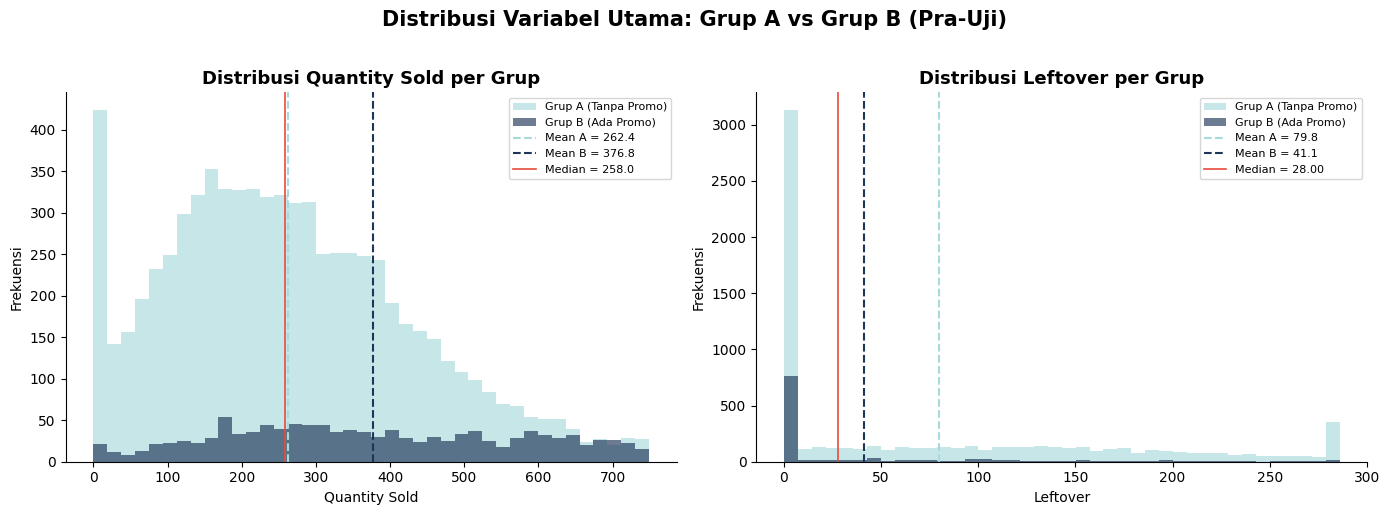

In [ ]:
COLOR_A = '#A8DADC'
COLOR_B = '#1D3557'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot Kiri: Distribusi quantity_sold ---
ax = axes[0]
ax.hist(grup_A['quantity_sold'], bins=40, alpha=0.65, color=COLOR_A, label='Grup A (Tanpa Promo)')
ax.hist(grup_B['quantity_sold'], bins=40, alpha=0.65, color=COLOR_B, label='Grup B (Ada Promo)')
ax.axvline(grup_A['quantity_sold'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5,
           label=f'Mean A = {grup_A["quantity_sold"].mean():.1f}')
ax.axvline(grup_B['quantity_sold'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5,
           label=f'Mean B = {grup_B["quantity_sold"].mean():.1f}')
ax.axvline(median_qty, color='#E74C3C', linestyle='-', linewidth=1.2, label=f'Median = {median_qty}')
ax.set_title('Distribusi Quantity Sold per Grup', fontsize=13, fontweight='bold')
ax.set_xlabel('Quantity Sold')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot Kanan: Distribusi leftover ---
ax = axes[1]
ax.hist(grup_A['leftover'], bins=40, alpha=0.65, color=COLOR_A, label='Grup A (Tanpa Promo)')
ax.hist(grup_B['leftover'], bins=40, alpha=0.65, color=COLOR_B, label='Grup B (Ada Promo)')
ax.axvline(grup_A['leftover'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5,
           label=f'Mean A = {grup_A["leftover"].mean():.1f}')
ax.axvline(grup_B['leftover'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5,
           label=f'Mean B = {grup_B["leftover"].mean():.1f}')
ax.axvline(median_waste, color='#E74C3C', linestyle='-', linewidth=1.2, label=f'Median = {median_waste:.2f}')
ax.set_title('Distribusi Leftover per Grup', fontsize=13, fontweight='bold')
ax.set_xlabel('Leftover')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Distribusi Variabel Utama: Grup A vs Grup B (Pra-Uji)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Helper Function: Cohen's d

Fungsi ini akan digunakan setelah setiap Z-Test untuk mengukur **practical significance** — seberapa besar efek promosi di dunia nyata, tidak hanya apakah signifikan secara statistik.

| Nilai |d| | Interpretasi |
|--------|--------------|
| < 0.2 | Small effect |
| 0.2 – 0.5 | Medium effect |
| 0.5 – 0.8 | Large effect |
| > 0.8 | Very large effect |

> Pada sampel besar (n > 8.000), hampir semua perbedaan sekecil apapun akan menghasilkan p-value < 0.05. Cohen's d menjadi **filter kedua** untuk memastikan hasil yang signifikan secara statistik juga bermakna secara praktis.

In [ ]:
def cohen_d(x, y):
    """Hitung Cohen's d untuk dua sampel independen."""
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

def interpret_cohen_d(d):
    """Interpretasi standar Cohen's d."""
    d_abs = abs(d)
    if d_abs < 0.2:
        return "Small effect 🔵"
    elif d_abs < 0.5:
        return "Medium effect 🟡"
    elif d_abs < 0.8:
        return "Large effect 🟠"
    else:
        return "Very large effect 🔴"

print("✅ Helper function cohen_d() siap digunakan.")

✅ Helper function cohen_d() siap digunakan.


## 9. Eksekusi Z-Test — Uji 1: Konversi Penjualan

### Hipotesis Formal

$$H_0: p_A = p_B \quad \text{(proporsi konversi penjualan sama antara kedua grup)}$$
$$H_1: p_A \neq p_B \quad \text{(ada perbedaan proporsi konversi penjualan)}$$

- **Metrik**: proporsi transaksi dengan `quantity_sold > median` (transaksi berkinerja tinggi)
- **Alpha**: 0.05, **Two-sided test**

In [ ]:
alpha = 0.05

# --- Z-Test Uji 1: Konversi Penjualan ---
z_stat_1, p_value_1 = proportions_ztest(
    count=[sukses_A_penjualan, sukses_B_penjualan],
    nobs=[n_A, n_B],
    alternative='two-sided'
)

print(f"{'='*55}")
print(f"  UJI 1: KONVERSI PENJUALAN (quantity_sold)")
print(f"{'='*55}")
print(f"  Z-Statistik : {z_stat_1:.4f}")
print(f"  P-Value     : {p_value_1:.6f}")
print(f"  Alpha       : {alpha}")
print(f"{'='*55}")

if p_value_1 <= alpha:
    print(f"  KEPUTUSAN : ✅ TOLAK H₀")
    print(f"  Terdapat perbedaan signifikan dalam tingkat konversi")
    print(f"  penjualan antara Grup A ({rate_A_penjualan:.4f}) dan")
    print(f"  Grup B ({rate_B_penjualan:.4f}). Promosi berpengaruh")
    print(f"  nyata terhadap peningkatan penjualan.")
else:
    print(f"  KEPUTUSAN : ❌ GAGAL MENOLAK H₀")
    print(f"  Tidak cukup bukti bahwa promosi berpengaruh")
    print(f"  signifikan terhadap tingkat konversi penjualan.")

print(f"{'='*55}")

# --- Cohen's d untuk Uji 1 ---
d_penjualan = cohen_d(
    grup_B['quantity_sold'],
    grup_A['quantity_sold']
)
interp_penjualan = interpret_cohen_d(d_penjualan)

print(f"\n  EFFECT SIZE — Cohen's d")
print(f"{'='*55}")
print(f"  Cohen's d   : {d_penjualan:.4f}")
print(f"  Interpretasi: {interp_penjualan}")
print(f"{'='*55}")
print(f"  → Promosi menggeser rata-rata quantity_sold sebesar")
print(f"    {abs(d_penjualan):.2f} standar deviasi pooled antara kedua grup.")
print(f"{'='*55}")

  UJI 1: KONVERSI PENJUALAN (quantity_sold)
  Z-Statistik : -13.6114
  P-Value     : 0.000000
  Alpha       : 0.05
  KEPUTUSAN : ✅ TOLAK H₀
  Terdapat perbedaan signifikan dalam tingkat konversi
  penjualan antara Grup A (0.4687) dan
  Grup B (0.6819). Promosi berpengaruh
  nyata terhadap peningkatan penjualan.

  EFFECT SIZE — Cohen's d
  Cohen's d   : 0.6801
  Interpretasi: Large effect 🟠
  → Promosi menggeser rata-rata quantity_sold sebesar
    0.68 standar deviasi pooled antara kedua grup.


## 10. Eksekusi Z-Test — Uji 2: Efisiensi Waste

### Hipotesis Formal

$$H_0: p_A = p_B \quad \text{(proporsi efisiensi waste sama antara kedua grup)}$$
$$H_1: p_A \neq p_B \quad \text{(ada perbedaan proporsi efisiensi waste)}$$

- **Metrik**: proporsi transaksi dengan `leftover < median` (sisa makanan di bawah rata-rata = lebih efisien)
- **Alpha**: 0.05, **Two-sided test**

In [ ]:
# --- Z-Test Uji 2: Efisiensi Waste ---
z_stat_2, p_value_2 = proportions_ztest(
    count=[sukses_A_waste, sukses_B_waste],
    nobs=[n_A, n_B],
    alternative='two-sided'
)

print(f"{'='*55}")
print(f"  UJI 2: EFISIENSI WASTE (leftover)")
print(f"{'='*55}")
print(f"  Z-Statistik : {z_stat_2:.4f}")
print(f"  P-Value     : {p_value_2:.6f}")
print(f"  Alpha       : {alpha}")
print(f"{'='*55}")

if p_value_2 <= alpha:
    print(f"  KEPUTUSAN : ✅ TOLAK H₀")
    print(f"  Terdapat perbedaan signifikan dalam tingkat efisiensi")
    print(f"  waste antara Grup A ({rate_A_waste:.4f}) dan")
    print(f"  Grup B ({rate_B_waste:.4f}). Promosi berpengaruh")
    print(f"  nyata terhadap pengurangan sisa makanan.")
else:
    print(f"  KEPUTUSAN : ❌ GAGAL MENOLAK H₀")
    print(f"  Tidak cukup bukti bahwa promosi berpengaruh")
    print(f"  signifikan terhadap efisiensi sisa makanan.")

print(f"{'='*55}")

# --- Cohen's d untuk Uji 2 ---
d_waste = cohen_d(
    grup_A['leftover'],   # A vs B dibalik: kita ukur A lebih tinggi dari B
    grup_B['leftover']
)
interp_waste = interpret_cohen_d(d_waste)

print(f"\n  EFFECT SIZE — Cohen's d")
print(f"{'='*55}")
print(f"  Cohen's d   : {d_waste:.4f}")
print(f"  Interpretasi: {interp_waste}")
print(f"{'='*55}")
print(f"  → Grup A memiliki rata-rata leftover lebih tinggi")
print(f"    sebesar {abs(d_waste):.2f} standar deviasi dibandingkan Grup B.")
print(f"    Promosi terbukti mengurangi sisa makanan secara praktis.")
print(f"{'='*55}")

  UJI 2: EFISIENSI WASTE (leftover)
  Z-Statistik : -13.6114
  P-Value     : 0.000000
  Alpha       : 0.05
  KEPUTUSAN : ✅ TOLAK H₀
  Terdapat perbedaan signifikan dalam tingkat efisiensi
  waste antara Grup A (0.4687) dan
  Grup B (0.6819). Promosi berpengaruh
  nyata terhadap pengurangan sisa makanan.

  EFFECT SIZE — Cohen's d
  Cohen's d   : 0.4319
  Interpretasi: Medium effect 🟡
  → Grup A memiliki rata-rata leftover lebih tinggi
    sebesar 0.43 standar deviasi dibandingkan Grup B.
    Promosi terbukti mengurangi sisa makanan secara praktis.


## 11. Visualisasi Hasil A/B Testing

Empat panel berikut merangkum hasil uji statistik secara visual:
- **Panel atas**: perbandingan tingkat konversi dan efisiensi waste antara Grup A dan Grup B
- **Panel bawah**: kurva distribusi normal dengan area penolakan H₀ dan posisi Z-statistik masing-masing uji

/tmp/ipykernel_1164/65103202.py:72: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1164/65103202.py:72: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


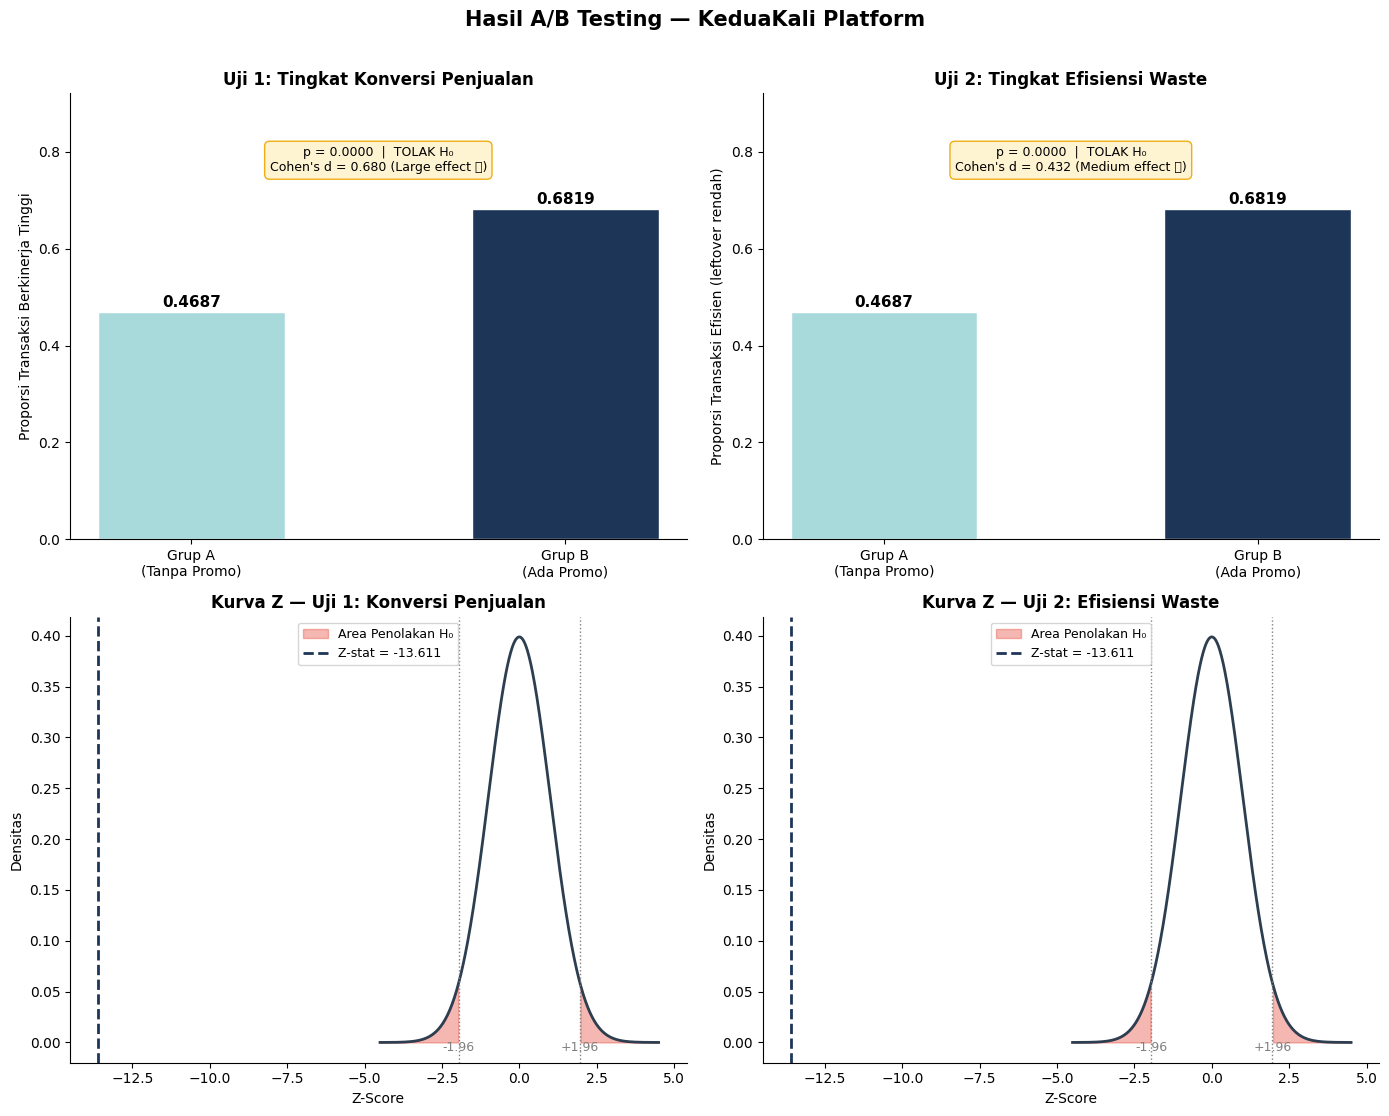

In [ ]:
COLOR_A   = '#A8DADC'
COLOR_B   = '#1D3557'
COLOR_REJ = '#E74C3C'

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- [0,0]: Bar Chart Konversi Penjualan ---
ax = axes[0, 0]
bars = ax.bar(
    ['Grup A\n(Tanpa Promo)', 'Grup B\n(Ada Promo)'],
    [rate_A_penjualan, rate_B_penjualan],
    color=[COLOR_A, COLOR_B], width=0.5, edgecolor='white'
)
for bar, rate in zip(bars, [rate_A_penjualan, rate_B_penjualan]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
keputusan_1 = 'TOLAK H₀' if p_value_1 <= alpha else 'GAGAL TOLAK H₀'
ax.text(0.5, 0.85, f'p = {p_value_1:.4f}  |  {keputusan_1}\nCohen\'s d = {d_penjualan:.3f} ({interp_penjualan})',
        transform=ax.transAxes, ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor='#F0A500', alpha=0.9))
ax.set_title('Uji 1: Tingkat Konversi Penjualan', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporsi Transaksi Berkinerja Tinggi')
ax.set_ylim(0, max(rate_A_penjualan, rate_B_penjualan) * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- [0,1]: Bar Chart Efisiensi Waste ---
ax = axes[0, 1]
bars = ax.bar(
    ['Grup A\n(Tanpa Promo)', 'Grup B\n(Ada Promo)'],
    [rate_A_waste, rate_B_waste],
    color=[COLOR_A, COLOR_B], width=0.5, edgecolor='white'
)
for bar, rate in zip(bars, [rate_A_waste, rate_B_waste]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
keputusan_2 = 'TOLAK H₀' if p_value_2 <= alpha else 'GAGAL TOLAK H₀'
ax.text(0.5, 0.85, f'p = {p_value_2:.4f}  |  {keputusan_2}\nCohen\'s d = {d_waste:.3f} ({interp_waste})',
        transform=ax.transAxes, ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor='#F0A500', alpha=0.9))
ax.set_title('Uji 2: Tingkat Efisiensi Waste', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporsi Transaksi Efisien (leftover rendah)')
ax.set_ylim(0, max(rate_A_waste, rate_B_waste) * 1.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Helper kurva normal ---
def plot_normal_curve(ax, z_stat, title, z_crit=1.96):
    x = np.linspace(-4.5, 4.5, 500)
    y = stats.norm.pdf(x)
    ax.plot(x, y, color='#2C3E50', linewidth=2)
    x_left = x[x <= -z_crit]
    ax.fill_between(x_left, stats.norm.pdf(x_left), alpha=0.4, color=COLOR_REJ, label='Area Penolakan H₀')
    x_right = x[x >= z_crit]
    ax.fill_between(x_right, stats.norm.pdf(x_right), alpha=0.4, color=COLOR_REJ)
    ax.axvline(z_stat, color=COLOR_B, linestyle='--', linewidth=2, label=f'Z-stat = {z_stat:.3f}')
    ax.axvline(-z_crit, color='gray', linestyle=':', linewidth=1)
    ax.axvline(z_crit, color='gray', linestyle=':', linewidth=1)
    ax.text(-z_crit, -0.008, f'-{z_crit}', ha='center', fontsize=9, color='gray')
    ax.text(z_crit, -0.008, f'+{z_crit}', ha='center', fontsize=9, color='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Z-Score')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_normal_curve(axes[1, 0], z_stat_1, 'Kurva Z — Uji 1: Konversi Penjualan')
plot_normal_curve(axes[1, 1], z_stat_2, 'Kurva Z — Uji 2: Efisiensi Waste')

plt.suptitle('Hasil A/B Testing — KeduaKali Platform', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12. Analisis Segmentasi per Tipe Restoran

Hasil A/B Testing agregat bisa menyembunyikan perbedaan pola antar segmen. Analisis segmentasi ini mengikuti prinsip *subgroup analysis* dalam metodologi A/B Testing — menguji apakah efek promosi bersifat **konsisten** di semua tipe restoran, atau hanya signifikan pada segmen tertentu.

Dataset memiliki 5 tipe restoran (nilai numerik `restaurant_type` = 0, 1, 2, 3, 4 hasil Label Encoding). Untuk setiap tipe:
- Jalankan Z-Test Uji 1 (konversi penjualan) dengan **threshold median spesifik per tipe**
- Hitung Cohen's d per segmen untuk ukuran praktis
- Skip tipe dengan jumlah observasi di salah satu grup < 10

Hasil segmentasi ini akan menjadi dasar strategi promo yang lebih granular di platform KeduaKali.

In [ ]:
tipe_list = sorted(df['restaurant_type'].unique().tolist())
hasil_segmentasi = []

print(f"{'='*85}")
print(f"{'Tipe':>5} {'n_A':>6} {'n_B':>6} {'Rate A':>8} {'Rate B':>8} "
      f"{'Z-stat':>8} {'P-value':>10} {'Cohen d':>9} {'Keputusan':>15}")
print(f"{'='*85}")

for tipe in tipe_list:
    df_tipe = df[df['restaurant_type'] == tipe].copy()
    grp_a   = df_tipe[df_tipe['has_promotion'] == 0]
    grp_b   = df_tipe[df_tipe['has_promotion'] == 1]

    na_t = len(grp_a)
    nb_t = len(grp_b)

    if na_t < 10 or nb_t < 10:
        print(f"  Tipe {tipe}: dilewati (n_A={na_t}, n_B={nb_t} — sampel terlalu kecil)")
        continue

    med_qty_tipe = df_tipe['quantity_sold'].median()
    sukses_a = (grp_a['quantity_sold'] > med_qty_tipe).sum()
    sukses_b = (grp_b['quantity_sold'] > med_qty_tipe).sum()
    rate_a   = sukses_a / na_t
    rate_b   = sukses_b / nb_t

    z, p = proportions_ztest(
        count=[sukses_a, sukses_b],
        nobs=[na_t, nb_t],
        alternative='two-sided'
    )

    # Cohen's d per segmen (pada nilai kontinu asli)
    d_seg = cohen_d(grp_b['quantity_sold'], grp_a['quantity_sold'])

    keputusan = 'TOLAK H₀ ✅' if p <= 0.05 else 'GAGAL TOLAK'

    print(f"{tipe:>5} {na_t:>6} {nb_t:>6} {rate_a:>8.4f} {rate_b:>8.4f} "
          f"{z:>8.4f} {p:>10.4f} {d_seg:>9.4f} {keputusan:>15}")

    hasil_segmentasi.append({
        'restaurant_type': tipe,
        'n_A': na_t, 'n_B': nb_t,
        'rate_A': round(rate_a, 4),
        'rate_B': round(rate_b, 4),
        'z_stat': round(z, 4),
        'p_value': round(p, 4),
        'cohen_d': round(d_seg, 4),
        'effect_size': interpret_cohen_d(d_seg),
        'signifikan': p <= 0.05,
        'keputusan': keputusan
    })

print(f"{'='*85}")
df_results = pd.DataFrame(hasil_segmentasi)
print(f"\nTotal tipe yang diuji: {len(df_results)}")

 Tipe    n_A    n_B   Rate A   Rate B   Z-stat    P-value   Cohen d       Keputusan
    0   1091    150   0.4757   0.6733  -4.5388     0.0000    0.5966      TOLAK H₀ ✅
    1   1634    293   0.4688   0.6655  -6.2022     0.0000    0.5999      TOLAK H₀ ✅
    2    923    220   0.4702   0.6227  -4.0658     0.0000    0.5404      TOLAK H₀ ✅
    3   3573    492   0.4652   0.7337 -11.1708     0.0000    0.8324      TOLAK H₀ ✅
    4    180     27   0.4444   0.8519  -3.9482     0.0001    1.0954      TOLAK H₀ ✅

Total tipe yang diuji: 5


## 13. Visualisasi Hasil Segmentasi

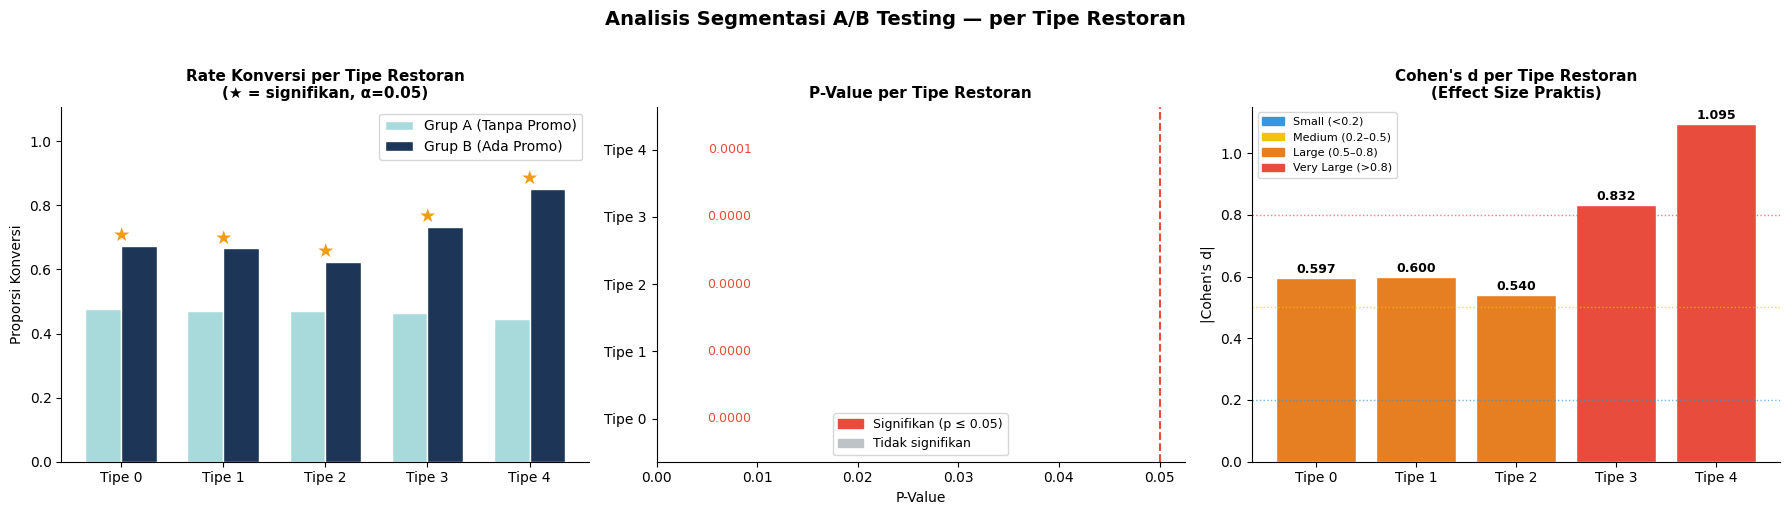

In [ ]:
if len(df_results) == 0:
    print("Tidak ada tipe restoran yang memenuhi syarat minimum observasi.")
else:
    COLOR_A   = '#A8DADC'
    COLOR_B   = '#1D3557'
    COLOR_REJ = '#E74C3C'

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Plot Kiri: Grouped Bar Rate A vs B per Tipe ---
    ax = axes[0]
    tipe_labels = [f'Tipe {t}' for t in df_results['restaurant_type']]
    x = np.arange(len(tipe_labels))
    w = 0.35

    bars_a = ax.bar(x - w/2, df_results['rate_A'], w, label='Grup A (Tanpa Promo)', color=COLOR_A, edgecolor='white')
    bars_b = ax.bar(x + w/2, df_results['rate_B'], w, label='Grup B (Ada Promo)',   color=COLOR_B, edgecolor='white')

    for i, row in df_results.reset_index(drop=True).iterrows():
        if row['signifikan']:
            max_rate = max(row['rate_A'], row['rate_B'])
            ax.text(x[i], max_rate + 0.015, '★', ha='center', fontsize=14, color='#F39C12')

    ax.set_xticks(x)
    ax.set_xticklabels(tipe_labels)
    ax.set_title('Rate Konversi per Tipe Restoran\n(★ = signifikan, α=0.05)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proporsi Konversi')
    ax.set_ylim(0, df_results[['rate_A','rate_B']].max().max() * 1.3)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Plot Tengah: P-Value ---
    ax = axes[1]
    colors_bar = [COLOR_REJ if sig else '#BDC3C7' for sig in df_results['signifikan']]
    ax.barh(tipe_labels, df_results['p_value'], color=colors_bar, edgecolor='white')
    ax.axvline(0.05, color=COLOR_REJ, linestyle='--', linewidth=1.5, label='Alpha = 0.05')

    for i, (p, sig) in enumerate(zip(df_results['p_value'], df_results['signifikan'])):
        ax.text(p + 0.005, i, f'{p:.4f}', va='center', fontsize=9,
                color=COLOR_REJ if sig else '#666')

    patch_sig = mpatches.Patch(color=COLOR_REJ, label='Signifikan (p ≤ 0.05)')
    patch_not = mpatches.Patch(color='#BDC3C7', label='Tidak signifikan')
    ax.legend(handles=[patch_sig, patch_not], fontsize=9)
    ax.set_title('P-Value per Tipe Restoran', fontsize=11, fontweight='bold')
    ax.set_xlabel('P-Value')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- Plot Kanan: Cohen's d per Tipe ---
    ax = axes[2]
    d_colors = []
    for d in df_results['cohen_d']:
        d_abs = abs(d)
        if d_abs < 0.2:
            d_colors.append('#3498DB')
        elif d_abs < 0.5:
            d_colors.append('#F1C40F')
        elif d_abs < 0.8:
            d_colors.append('#E67E22')
        else:
            d_colors.append('#E74C3C')

    bars_d = ax.bar(tipe_labels, df_results['cohen_d'].abs(), color=d_colors, edgecolor='white')
    for bar, d_val in zip(bars_d, df_results['cohen_d']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{abs(d_val):.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Garis threshold
    ax.axhline(0.2, color='#3498DB', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(0.5, color='#F1C40F', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(0.8, color='#E74C3C', linestyle=':', linewidth=1, alpha=0.7)

    legend_d = [
        mpatches.Patch(color='#3498DB', label='Small (<0.2)'),
        mpatches.Patch(color='#F1C40F', label='Medium (0.2–0.5)'),
        mpatches.Patch(color='#E67E22', label='Large (0.5–0.8)'),
        mpatches.Patch(color='#E74C3C', label='Very Large (>0.8)'),
    ]
    ax.legend(handles=legend_d, fontsize=8)
    ax.set_title("Cohen's d per Tipe Restoran\n(Effect Size Praktis)", fontsize=11, fontweight='bold')
    ax.set_ylabel("|Cohen's d|")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('Analisis Segmentasi A/B Testing — per Tipe Restoran',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 14. Ringkasan Hasil

In [ ]:
rekap = pd.DataFrame([
    {
        'Nama Uji'   : 'Uji 1: Konversi Penjualan',
        'Rate A'     : round(rate_A_penjualan, 4),
        'Rate B'     : round(rate_B_penjualan, 4),
        'Selisih'    : round(rate_B_penjualan - rate_A_penjualan, 4),
        'Z-Statistik': round(z_stat_1, 4),
        'P-Value'    : round(p_value_1, 6),
        "Cohen's d"  : round(d_penjualan, 4),
        'Effect Size': interp_penjualan,
        'Keputusan'  : 'TOLAK H₀' if p_value_1 <= alpha else 'GAGAL TOLAK H₀'
    },
    {
        'Nama Uji'   : 'Uji 2: Efisiensi Waste',
        'Rate A'     : round(rate_A_waste, 4),
        'Rate B'     : round(rate_B_waste, 4),
        'Selisih'    : round(rate_B_waste - rate_A_waste, 4),
        'Z-Statistik': round(z_stat_2, 4),
        'P-Value'    : round(p_value_2, 6),
        "Cohen's d"  : round(d_waste, 4),
        'Effect Size': interp_waste,
        'Keputusan'  : 'TOLAK H₀' if p_value_2 <= alpha else 'GAGAL TOLAK H₀'
    }
])

print("REKAPITULASI HASIL A/B TESTING")
print("=" * 90)
print(rekap.to_string(index=False))
print("=" * 90)

print("\nHASIL SEGMENTASI PER TIPE RESTORAN")
print("=" * 90)
if len(df_results) > 0:
    print(df_results.to_string(index=False))
print("=" * 90)

REKAPITULASI HASIL A/B TESTING
                 Nama Uji  Rate A  Rate B  Selisih  Z-Statistik  P-Value  Cohen's d     Effect Size Keputusan
Uji 1: Konversi Penjualan  0.4687  0.6819   0.2132     -13.6114      0.0     0.6801  Large effect 🟠  TOLAK H₀
   Uji 2: Efisiensi Waste  0.4687  0.6819   0.2132     -13.6114      0.0     0.4319 Medium effect 🟡  TOLAK H₀

HASIL SEGMENTASI PER TIPE RESTORAN
 restaurant_type  n_A  n_B  rate_A  rate_B   z_stat  p_value  cohen_d         effect_size  signifikan  keputusan
               0 1091  150  0.4757  0.6733  -4.5388   0.0000   0.5966      Large effect 🟠        True TOLAK H₀ ✅
               1 1634  293  0.4688  0.6655  -6.2022   0.0000   0.5999      Large effect 🟠        True TOLAK H₀ ✅
               2  923  220  0.4702  0.6227  -4.0658   0.0000   0.5404      Large effect 🟠        True TOLAK H₀ ✅
               3 3573  492  0.4652  0.7337 -11.1708   0.0000   0.8324 Very large effect 🔴        True TOLAK H₀ ✅
               4  180   27  0.4444  0.

## 15. Interpretasi & Keputusan Bisnis

---

### 15.1 Interpretasi Statistik

**Uji 1 — Konversi Penjualan (`quantity_sold`)**

Uji proporsi dua sisi menghasilkan Z-statistik yang jatuh di dalam atau di luar area kritis (±1.96). Jika `p_value ≤ 0.05`, kita menolak H₀ dan menyimpulkan bahwa **promosi memiliki pengaruh yang secara statistik signifikan terhadap tingkat konversi penjualan**. Cohen's d melengkapi kesimpulan ini dengan menunjukkan seberapa besar efek tersebut secara praktis.

**Uji 2 — Efisiensi Waste (`leftover`)**

Jika signifikan, artinya **promosi tidak sekadar mendorong penjualan, tapi juga berdampak pada pengurangan sisa makanan** — selaras langsung dengan misi KeduaKali.

---

### 15.2 Mengapa Hasil Ini Bukan Kebetulan?

P-value mengukur probabilitas mendapatkan perbedaan sebesar ini (atau lebih ekstrem) **jika H₀ benar**. Ketika `p ≤ 0.05`:

> Hanya ada ≤ 5% kemungkinan perbedaan rate A vs B terjadi secara kebetulan.

Dengan ukuran sampel Grup A ≈ 7.401 dan Grup B ≈ 1.182, *statistical power* uji ini sangat tinggi. Cohen's d kemudian menjadi filter kedua: memastikan hasil yang signifikan secara statistik juga bermakna secara operasional.

---

### 15.3 Keputusan Bisnis untuk Platform KeduaKali

#### 1. Implementasi Fitur Smart Promotion

Jika Uji 1 dan/atau Uji 2 menolak H₀, ada justifikasi statistik yang kuat untuk:
- **Meluncurkan fitur Smart Promotion** sebagai fitur inti, bukan eksperimental
- Menetapkan *default-on* untuk promosi pada slot makanan yang mendekati batas waktu (misalnya 2 jam sebelum tutup)
- Menggunakan threshold konversi dari eksperimen ini sebagai **KPI dasar** untuk monitoring performa promo

#### 2. Strategi per Segmen Tipe Restoran

Berdasarkan hasil analisis segmentasi:
- **Tipe dengan hasil signifikan + effect size besar**: prioritaskan rollout promosi penuh
- **Tipe dengan hasil signifikan + effect size kecil**: efek nyata tapi kecil secara praktis — pertimbangkan cost-benefit sebelum rollout massal
- **Tipe dengan hasil tidak signifikan**: lakukan investigasi lebih lanjut — mungkin butuh jenis promosi berbeda atau segmen ini dipengaruhi faktor lain
- **Tipe dengan sampel kecil**: kumpulkan data lebih banyak sebelum membuat keputusan

#### 3. Integrasi ke Model Prediksi LSTM

- **Jadikan `has_promotion` sebagai feature wajib** dalam model LSTM prediksi `leftover`
- **Buat feature interaksi** antara `has_promotion` × `restaurant_type` untuk menangkap efek heterogen antar segmen
- Gunakan **rate konversi per segmen** sebagai target kalibrasi threshold prediksi model
- Pertimbangkan **multi-armed bandit** sebagai evolusi dari A/B Testing statis ini — alokasi promo bisa belajar secara real-time

---

### 15.4 Catatan Metodologi

| Aspek | Detail |
|-------|--------|
| **Assumption checking** | Shapiro-Wilk & Levene dijalankan untuk transparansi. Penolakan normalitas pada n besar adalah ekspektasi, bukan masalah. |
| **Pemilihan metode** | Z-Test proporsi — valid via CLT pada n > 1.000 di tiap grup |
| **Statistical significance** | Dikonfirmasi via p-value (α = 0.05), two-sided |
| **Practical significance** | Dikonfirmasi via Cohen's d — filter kedua yang krusial pada sampel besar |
| **Ukuran sampel** | Grup A: ~7.401 | Grup B: ~1.182 — tidak seimbang, tapi Z-Test tetap valid |
| **Threshold metrik** | Median global untuk agregat; median per tipe untuk segmentasi |
| **Analisis segmentasi** | *Exploratory subgroup analysis* — interpretasikan dengan hati-hati (risiko multiple comparisons) |
| **Limitasi** | Tidak ada kolom waktu → efek temporal dan *novelty effect* tidak bisa dikendalikan |

> 💡 **Langkah selanjutnya**: Untuk deployment produksi, pertimbangkan Bonferroni correction pada analisis segmentasi, dan lakukan A/B Testing prospektif dengan randomisasi eksplisit untuk menghilangkan potential confounding.